# Predykcja cen samochodów używanych — regresja

**Zbiór danych:** [Used Car Price Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset)

**Cel:** Przewidzenie ceny samochodu używanego na podstawie jego parametrów technicznych i historii pojazdu.

**Modele:** MLPRegressor (scikit-learn), RandomForestRegressor, SVR, MLP (TensorFlow/Keras)

**Potok przetwarzania:**
1. Wczytanie i eksploracja danych (EDA)
2. Czyszczenie: parsowanie kolumn tekstowych, ekstrakcja cech numerycznych z `engine`
3. Usunięcie wartości odstających metodą IQR
4. Preprocessing: LabelEncoder + MinMaxScaler
5. Wizualizacje analityczne
6. Trenowanie i optymalizacja modeli
7. Porównanie wyników

## Instalacja zależności i import bibliotek

In [ ]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub

from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Wczytanie danych

Dane pobierane są bezpośrednio z Kaggle za pomocą biblioteki kagglehub.

In [ ]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "taeefnajib/used-car-price-prediction-dataset",
    "used_cars.csv",
)

df.head()

100%|██████████| 594k/594k [00:00<00:00, 2.06MB/s]


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 2. Eksploracja danych (EDA)

### 2.1 Podstawowe informacje o zbiorze

Surowy zbiór zawiera:

- 4009 wierszy i 12 kolumn
- Cechy tekstowe: `brand`, `model`, `fuel_type`, `engine`, `transmission`, `ext_col`, `int_col`, `accident`, `clean_title`
- Cechy numeryczne: `model_year`
- Cechy wymagające parsowania: `milage` (tekst z " mi."), `price` (tekst z "$")

In [ ]:
print(f'Wymiary zbioru: {df.shape}')

Wymiary zbioru: (4009, 12)


In [ ]:
print(f'Kolumny: {df.columns.tolist()}')

Kolumny: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


In [ ]:
print('Typy danych:')
print(df.dtypes)

Typy danych:
brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object


### 2.2 Pierwsze 10 rekordów

In [ ]:
df.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


### 2.3 Statystyki opisowe

In [ ]:
df.describe()

,model_year
count,4009.00
mean,2015.52
std,6.10
min,1974.00
25%,2012.00
50%,2017.00
75%,2020.00
max,2024.00


In [ ]:
df.describe(include="O")

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


### 2.4 Brakujące wartości i duplikaty

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


## 3. Czyszczenie danych

### 3.1 Parsowanie kolumny `price`

In [ ]:
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)\
                                      .str.replace(',', '', regex=False)\
                                      .astype(float)
print('Zakres cen (USD):', df['price'].min(), '—', df['price'].max())

Zakres cen (USD): 2000.0 — 2954083.0


### 3.2 Parsowanie kolumny `milage`

In [ ]:
df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False)\
                                        .str.replace(',', '', regex=False)\
                                        .astype(float)
print('Zakres przebiegu (mil):', df['milage'].min(), '—', df['milage'].max())

Zakres przebiegu (mil): 100.0 — 405000.0


### 3.3 Ekstrakcja cech numerycznych z kolumny `engine`

Kolumna `engine` zawiera surowy tekst, np. `300.0HP 3.7L V6 Cylinder Engine`. Wyciągamy z niej trzy cechy numeryczne:
- **horsepower** — moc silnika w KM
- **engine_size** — pojemność silnika w litrach
- **cylinders** — liczba cylindrów

In [ ]:
df['hp'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

In [ ]:
df['engine_size'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)

In [ ]:
df['cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)

In [ ]:
print(f'Horsepower — brak: {df["hp"].isna().sum()}, '
      f'zakres: {df["hp"].min():.0f}–{df["hp"].max():.0f} HP')
print(f'Engine size — brak: {df["engine_size"].isna().sum()}, '
      f'zakres: {df["engine_size"].min():.1f}–{df["engine_size"].max():.1f} L')
print(f'Cylinders — brak: {df["cylinders"].isna().sum()}, '
      f'zakres: {df["cylinders"].min():.1f}–{df["cylinders"].max():.1f}')

Horsepower — brak: 808, zakres: 70–1020 HP
Engine size — brak: 377, zakres: 0.7–8.4 L
Cylinders — brak: 945, zakres: 3.0–12.0


### 3.4 Kodowanie kolumn binarnych

- **accident**: `At least 1 accident...` → 1, `None reported` → 0

In [ ]:
df['accident'] = df['accident'].map({
    'None reported':0,
    'At least 1 accident or damage reported':1
})
print('Rozkład:', df['accident'].value_counts())


Rozkład: accident
0.00    2910
1.00     986
Name: count, dtype: int64


### 3.5 Uproszczenie kolumny `transmission`

Kolumna zawiera wiele wariantów tekstowych. Grupujemy je do trzech kategorii: Manual, Automatic, Other.

In [ ]:
def simplify_transmission(x):
    x = str(x)

    if 'A/T' in x or 'Automatic' in x:
        return 'Automatic'
    elif 'M/T' in x or 'Manual' in x:
        return 'Manual'
    elif 'CVT' in x:
        return 'CVT'
    else:
        return 'Other'

df['transmission'] = df['transmission'].apply(simplify_transmission)
print('Rozkład:', df['transmission'].value_counts())

Rozkład: transmission
Automatic    3148
Other         426
Manual        372
CVT            63
Name: count, dtype: int64


### 3.6 Uproszczenie kolumny `fuel_type`

In [ ]:
def simplify_fuel(f):
    if pd.isna(f):
        return 'Other'
    f = str(f).lower()
    if 'gasoline' in f or 'gas' in f:
        return 'Gasoline'
    elif 'hybrid' in f:
        return 'Hybrid'
    elif 'diesel' in f:
        return 'Diesel'
    elif 'flex' in f or 'e85' in f:
        return 'Flex'
    return 'Other'

df['fuel_type'] = df['fuel_type'].apply(simplify_fuel)
print('Rozkład:', df['fuel_type'].value_counts())

Rozkład: fuel_type
Gasoline    3309
Hybrid       228
Other        217
Flex         139
Diesel       116
Name: count, dtype: int64


### 3.7 Uproszczenie kolumn `ext_col` i `int_color`


In [ ]:
main_colors = ['Black','White','Gray','Silver','Blue','Red']

df['ext_col'] = df['ext_col'].apply(
    lambda x: x if x in main_colors else 'Other'
)

df['int_col'] = df['int_col'].apply(
    lambda x: x if x in main_colors else 'Other'
)

In [ ]:
print('Rozkład:', df['ext_col'].value_counts())

Rozkład: ext_col
Black     905
White     816
Other     808
Gray      496
Silver    374
Blue      349
Red       261
Name: count, dtype: int64


In [ ]:
print('Rozkład:', df['int_col'].value_counts())

Rozkład: int_col
Black     2025
Other     1214
Gray       472
White      127
Red        126
Blue        29
Silver      16
Name: count, dtype: int64


### 3.8 Uproszczenie kolumn `brand` i `model`


In [ ]:
df['brand'].unique().tolist()

['Ford',
 'Hyundai',
 'Lexus',
 'INFINITI',
 'Audi',
 'Acura',
 'BMW',
 'Tesla',
 'Land',
 'Aston',
 'Toyota',
 'Lincoln',
 'Jaguar',
 'Mercedes-Benz',
 'Dodge',
 'Nissan',
 'Genesis',
 'Chevrolet',
 'Kia',
 'Jeep',
 'Bentley',
 'Honda',
 'Lucid',
 'MINI',
 'Porsche',
 'Hummer',
 'Chrysler',
 'Volvo',
 'Cadillac',
 'Lamborghini',
 'Maserati',
 'Volkswagen',
 'Subaru',
 'Rivian',
 'GMC',
 'RAM',
 'Alfa',
 'Ferrari',
 'Scion',
 'Mitsubishi',
 'Mazda',
 'Saturn',
 'Bugatti',
 'Polestar',
 'Rolls-Royce',
 'McLaren',
 'Buick',
 'Lotus',
 'Pontiac',
 'FIAT',
 'Karma',
 'Saab',
 'Mercury',
 'Plymouth',
 'smart',
 'Maybach',
 'Suzuki']

In [ ]:
brand_fix = {
    'Land':   'Land Rover',
    'Aston':  'Aston Martin',
    'Alfa':   'Alfa Romeo',
    'smart':  'Smart',
    'MINI':   'Mini',
    'FIAT':   'Fiat',
    'RAM':    'Ram',
    'INFINITI': 'Infiniti',
}
df['brand'] = df['brand'].replace(brand_fix)

top_brands = df['brand'].value_counts().head(30).index
df['brand'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

print('Rozkład:', df['brand'].value_counts())

Rozkład: brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Other            265
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land Rover       130
Nissan           116
Cadillac         107
GMC               91
Ram               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Mazda             64
Subaru            64
Acura             64
Honda             63
Infiniti          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Mini              33
Bentley           33
Name: count, dtype: int64


In [ ]:
def extract_model(row):
    brand = str(row['brand'])
    model = str(row['model'])
    parts = model.split()

    if not parts:
        return 'Other'

    two_word_brands = {
        'Tesla',
        'Land Rover',
        'Mercedes-Benz',
        'Jeep'
    }

    ambiguous_first = {'Grand', 'Range', 'Model', 'Super'}

    if brand in two_word_brands or parts[0] in ambiguous_first:
        return ' '.join(parts[:2]) if len(parts) >= 2 else parts[0]

    return parts[0]

df['model_main'] = df.apply(extract_model, axis=1)

top_models = df['model_main'].value_counts().head(30).index
df['model_main'] = df['model_main'].apply(lambda x: x if x in top_models else 'Other')

print('Rozkład:', df['model_main'].value_counts())

Rozkład: model_main
Other                 2802
Rover Range             97
911                     80
F-150                   64
Mustang                 61
Corvette                61
1500                    56
F-250                   47
Silverado               46
Escalade                45
Camaro                  45
E-Class E               41
X5                      38
Suburban                38
M3                      37
Wrangler Unlimited      34
Expedition              34
RX                      33
Sierra                  31
Yukon                   30
Cayenne                 30
Explorer                29
Model Y                 27
Bronco                  27
GX                      26
Grand Cherokee          26
Highlander              26
Tundra                  25
4Runner                 25
Challenger              24
S-Class S               24
Name: count, dtype: int64


### 3.9 Inżynieria cech – wiek pojazdu


In [ ]:
df['car_age'] = 2026 - df['model_year']

### 3.10 Usunięcie zbędnych kolumn





In [ ]:
df = df.drop(columns=['engine', 'model', 'model_year', 'clean_title'])
print(f'Kształt po usunięciu kolumn: {df.shape}')
print('Pozostałe kolumny:', df.columns.tolist())

Kształt po usunięciu kolumn: (4009, 13)
Pozostałe kolumny: ['brand', 'milage', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'price', 'hp', 'engine_size', 'cylinders', 'model_main', 'car_age']


### 3.11 Uzupełnienie wartości brakujących

In [ ]:
df['hp'].fillna(df['hp'].median(), inplace=True)
df['engine_size'].fillna(df['engine_size'].median(), inplace=True)
df['cylinders'].fillna(df['cylinders'].median(), inplace=True)
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])

In [ ]:
df.isna().sum()

,0
brand,0
milage,0
fuel_type,0
transmission,0
ext_col,0
int_col,0
accident,0
price,0
hp,0
engine_size,0


### 3.12 Identyfikacja kolumn kategorycznych i numerycznych

In [ ]:
TARGET = 'price'

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

print(f'Cechy kategoryczne ({len(cat_cols)}): {cat_cols}')
print(f'Cechy numeryczne ({len(num_cols)}):  {num_cols}')

Cechy kategoryczne (6): ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'model_main']
Cechy numeryczne (6):  ['milage', 'accident', 'hp', 'engine_size', 'cylinders', 'car_age']


### 3.13. Usunięcie wartości odstających metodą IQR

Wartości odstające w kolumnach `price` i `milage` mogą zaburzać uczenie modeli. Zastosowano metodę rozstępu ćwiartkowego (IQR): usunięto obserwacje poza zakresem [Q1 − 1.5·IQR, Q3 + 1.5·IQR].

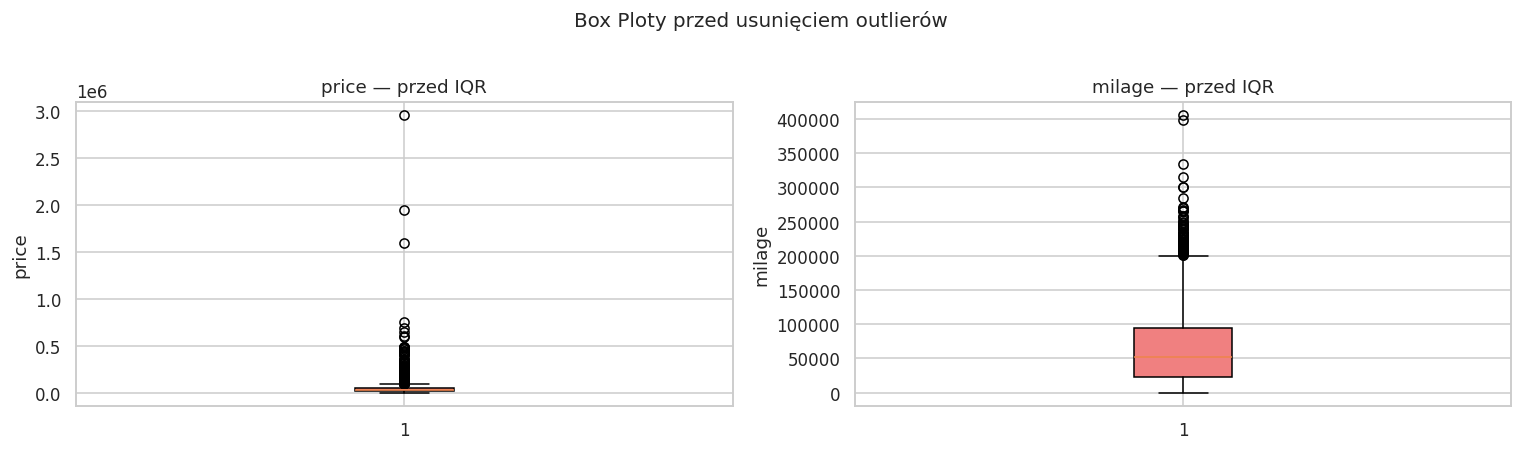

In [ ]:
iqr_cols = [TARGET, 'milage']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, iqr_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='black'))
    ax.set_title(f'{col} — przed IQR')
    ax.set_ylabel(col)
plt.suptitle('Box Ploty przed usunięciem outlierów', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        print(f'  {col:15s}: usunięto {outliers:5,} wierszy (> {upper:.1f})')
    return df_clean.reset_index(drop=True)

In [ ]:
n_before = len(df)
print(f'Wiersze przed IQR: {n_before:,}')
df = remove_outliers_iqr(df, iqr_cols)
print(f'Wiersze po IQR: {len(df):,}  (usunięto łącznie: {n_before - len(df):,})')

Wiersze przed IQR: 4,009
  price          : usunięto   244 wierszy (> 99175.0)
  milage         : usunięto    65 wierszy (> 202600.0)
Wiersze po IQR: 3,700  (usunięto łącznie: 309)


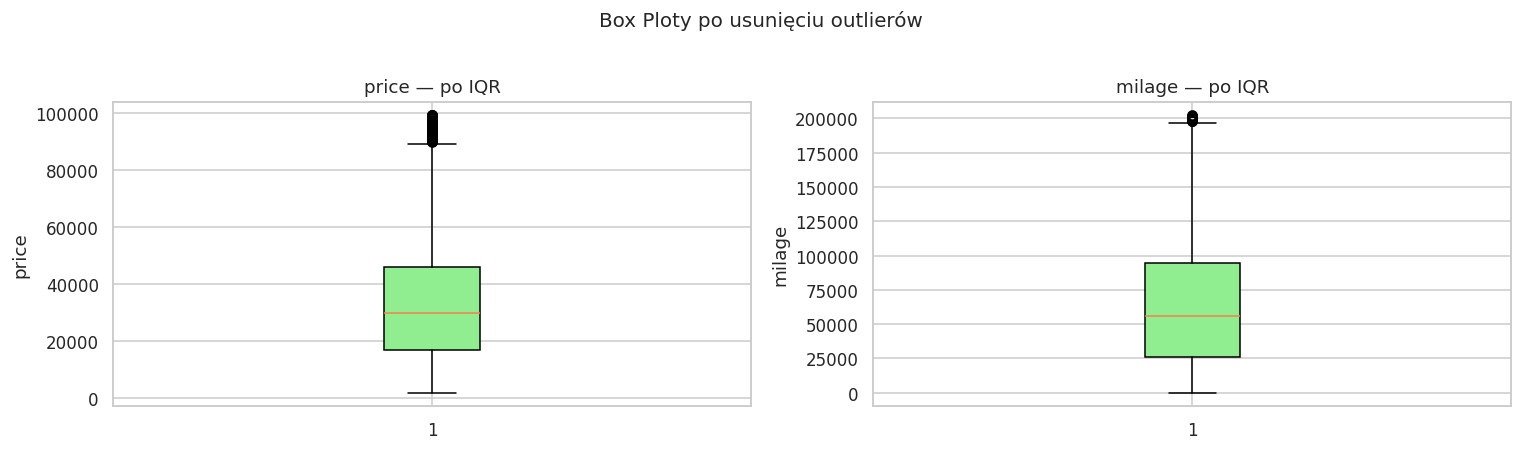

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, iqr_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightgreen', color='black'))
    ax.set_title(f'{col} — po IQR')
    ax.set_ylabel(col)
plt.suptitle('Box Ploty po usunięciu outlierów', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Wizualizacje analityczne

### 4.1 Rozkład cen samochodów

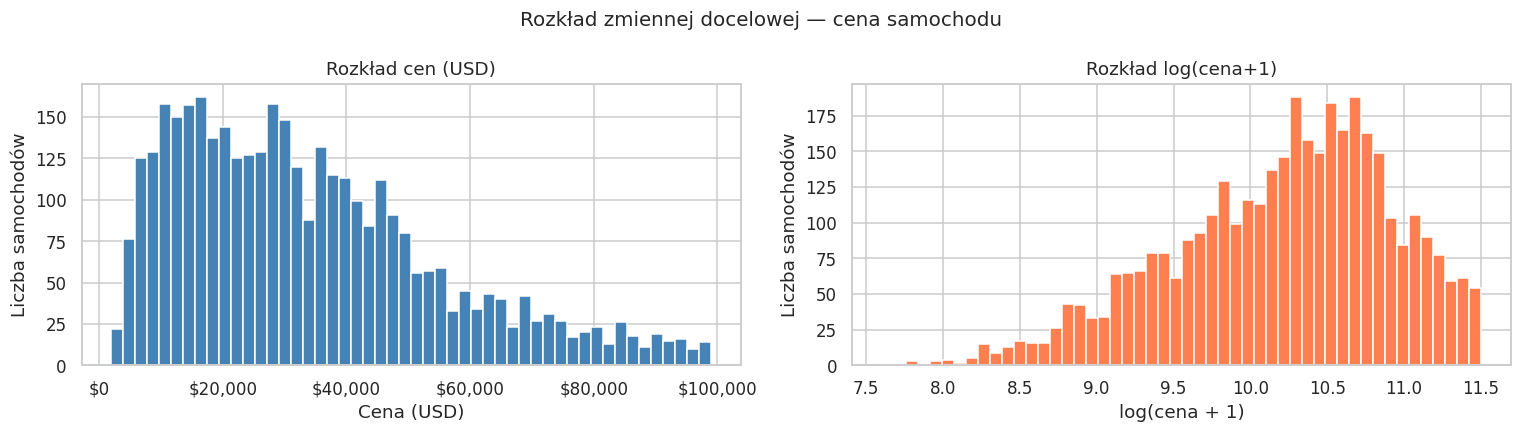

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Rozkład cen (USD)')
axes[0].set_xlabel('Cena (USD)')
axes[0].set_ylabel('Liczba samochodów')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

log_price = np.log1p(df[TARGET])
axes[1].hist(log_price, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Rozkład log(cena+1)')
axes[1].set_xlabel('log(cena + 1)')
axes[1].set_ylabel('Liczba samochodów')

plt.suptitle('Rozkład zmiennej docelowej — cena samochodu', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Cena vs przebieg (milage)

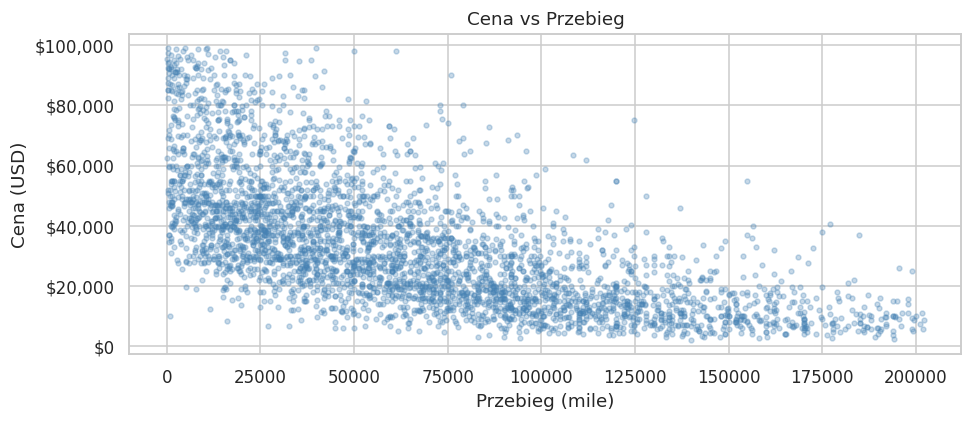

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(df['milage'], df[TARGET], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Przebieg (mile)')
ax.set_ylabel('Cena (USD)')
ax.set_title('Cena vs Przebieg')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 4.3 Cena vs rok produkcji

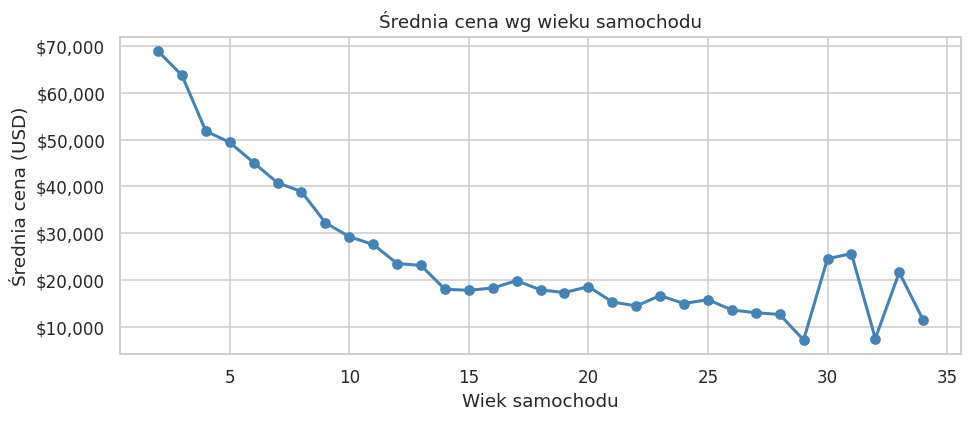

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
year_price = df.groupby('car_age')[TARGET].mean().reset_index()
ax.plot(year_price['car_age'], year_price[TARGET], marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Wiek samochodu')
ax.set_ylabel('Średnia cena (USD)')
ax.set_title('Średnia cena wg wieku samochodu')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 4.4 Cena vs moc silnika (horsepower)

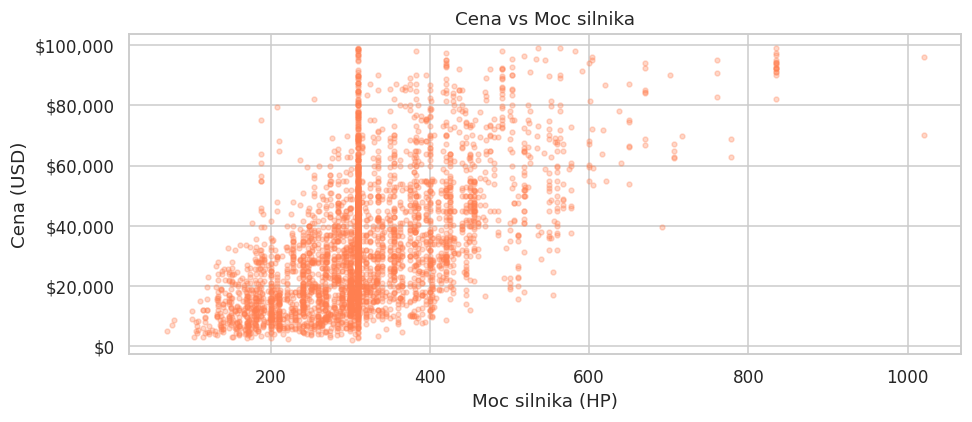

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(df['hp'], df[TARGET], alpha=0.3, s=10, color='coral')
ax.set_xlabel('Moc silnika (HP)')
ax.set_ylabel('Cena (USD)')
ax.set_title('Cena vs Moc silnika')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 4.5 Macierz korelacji

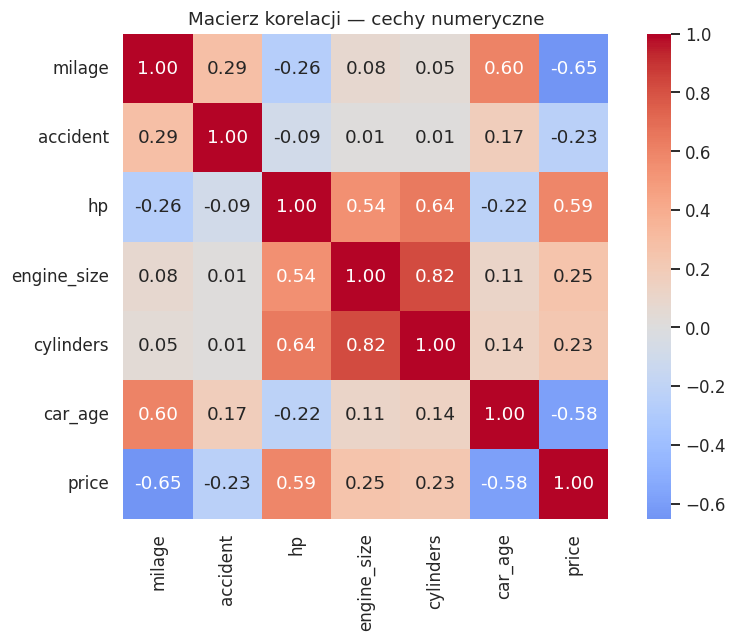

In [ ]:
corr = df[num_cols + ['price']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Macierz korelacji — cechy numeryczne')
plt.tight_layout()
plt.show()

## Wnioski

- **Przebieg (`milage`)** najsilniej ujemnie koreluje z ceną (-0.65) — im więcej km, tym niższa cena
- **Moc (`hp`)** najsilniej dodatnio koreluje z ceną (+0.59) — mocniejsze auta są droższe
- **Wiek (`car_age`)** również obniża cenę (-0.58) — starsze auta warte mniej
- **`engine_size` i `cylinders`** są silnie skorelowane ze sobą (0.82) — redundantne cechy
- **Historia wypadków (`accident`)** ma słaby wpływ na cenę (+0.29)

### 4.6 Rozkład cech numerycznych

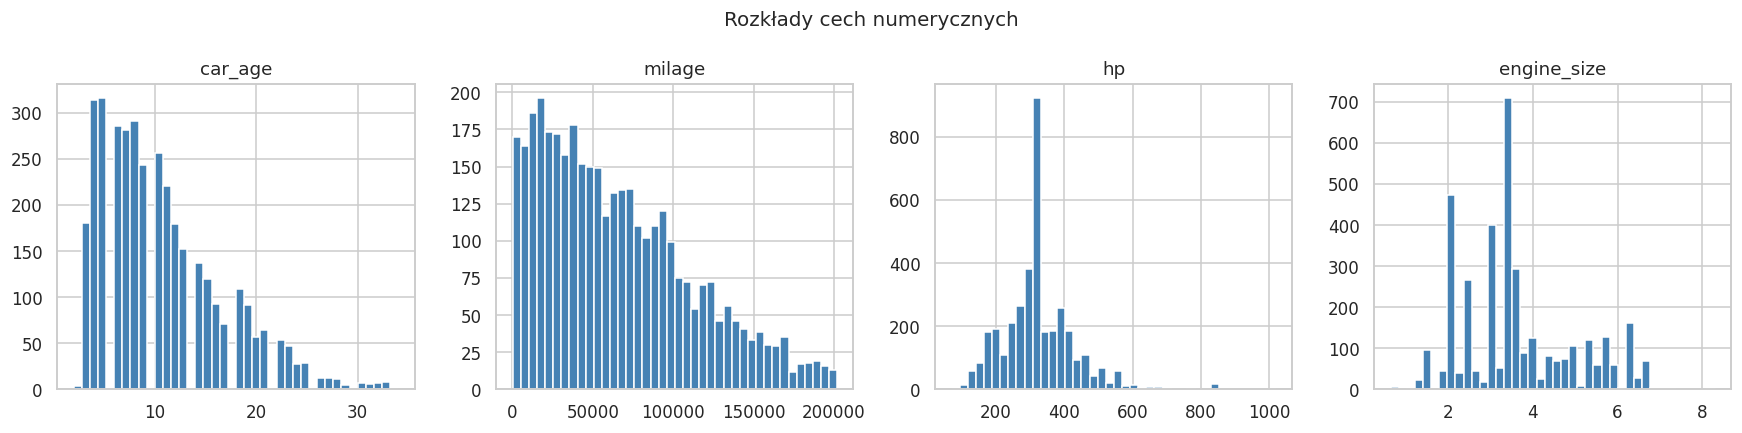

In [ ]:
plot_cols = ['car_age', 'milage', 'hp', 'engine_size']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, plot_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Rozkłady cech numerycznych', fontsize=13)
plt.tight_layout()
plt.show()

### 4.7 Cena wg marki samochodu

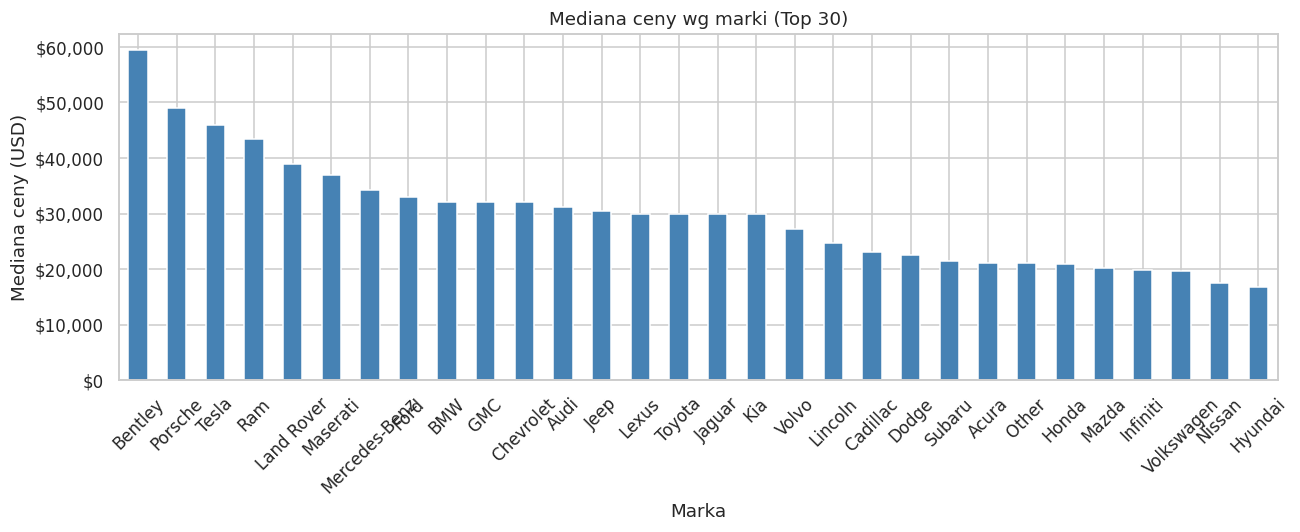

In [ ]:
brand_price = df.groupby('brand')[TARGET].median().sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(12, 5))
brand_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Mediana ceny wg marki (Top 30)')
ax.set_xlabel('Marka')
ax.set_ylabel('Mediana ceny (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4.8 Cena wg skrzyni biegów

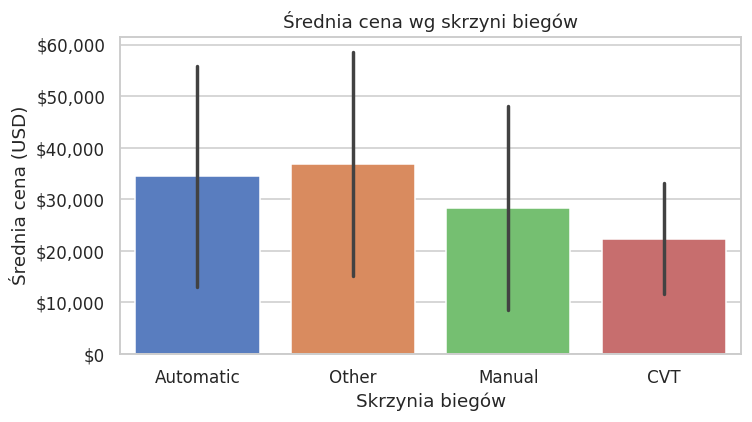

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df, x='transmission', y=TARGET,
            estimator=np.mean, errorbar='sd',
            palette='muted', ax=ax)
ax.set_title('Średnia cena wg skrzyni biegów')
ax.set_xlabel('Skrzynia biegów')
ax.set_ylabel('Średnia cena (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 4.9 Cena wg typu paliwa

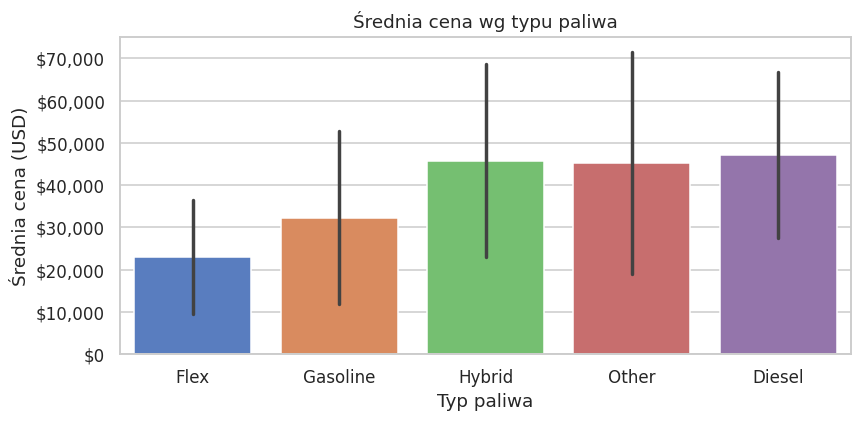

In [ ]:
dfig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='fuel_type', y=TARGET,
            estimator=np.mean, errorbar='sd',
            palette='muted', ax=ax)
ax.set_title('Średnia cena wg typu paliwa')
ax.set_xlabel('Typ paliwa')
ax.set_ylabel('Średnia cena (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 4.10 Wpływ wypadku na cenę

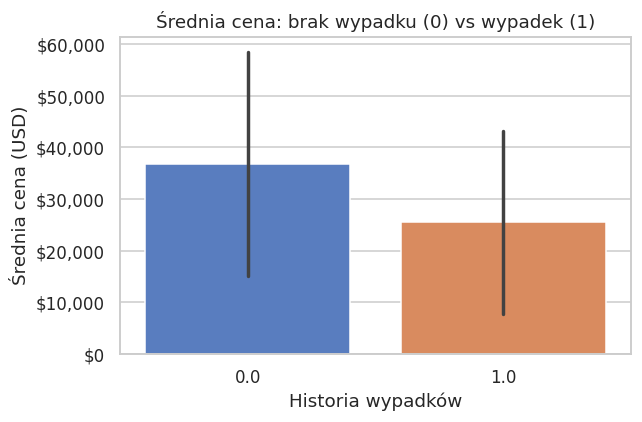

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x='accident', y=TARGET,
            estimator=np.mean, errorbar='sd',
            palette='muted', ax=ax)
ax.set_title('Średnia cena: brak wypadku (0) vs wypadek (1)')
ax.set_xlabel('Historia wypadków')
ax.set_ylabel('Średnia cena (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 5. Przygotowanie danych do modelowania
### 5.1 Label Encoding kolumn kategorycznych

**LabelEncoder** przekształca wartości tekstowe (kategorie) na liczby całkowite — każda unikalna wartość otrzymuje przypisany numer, np. `'Audi'→0, 'BMW'→1, 'Ford'→2`.

In [ ]:
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [ ]:
df.head()

,brand,milage,fuel_type,transmission,ext_col,int_col,accident,price,hp,engine_size,cylinders,model_main,car_age
0,7,51000.00,1,0,0,0,1.00,10300.00,300.00,3.70,6.00,20,13
1,10,34742.00,2,0,3,2,1.00,38005.00,310.00,3.80,6.00,20,5
2,16,22372.00,2,0,1,0,0.00,54598.00,310.00,3.50,6.00,21,4
3,11,88900.00,3,0,0,0,0.00,15500.00,354.00,3.50,6.00,20,11
4,1,9835.00,2,0,3,0,0.00,34999.00,310.00,2.00,6.00,20,5


### 5.2 Transformacja logarytmiczna zmiennej docelowej

Cena samochodów ma rozkład prawostronnie skośny. Transformacja `log1p(price)` przybliża rozkład do normalnego, co stabilizuje uczenie modeli i poprawia ich skuteczność.

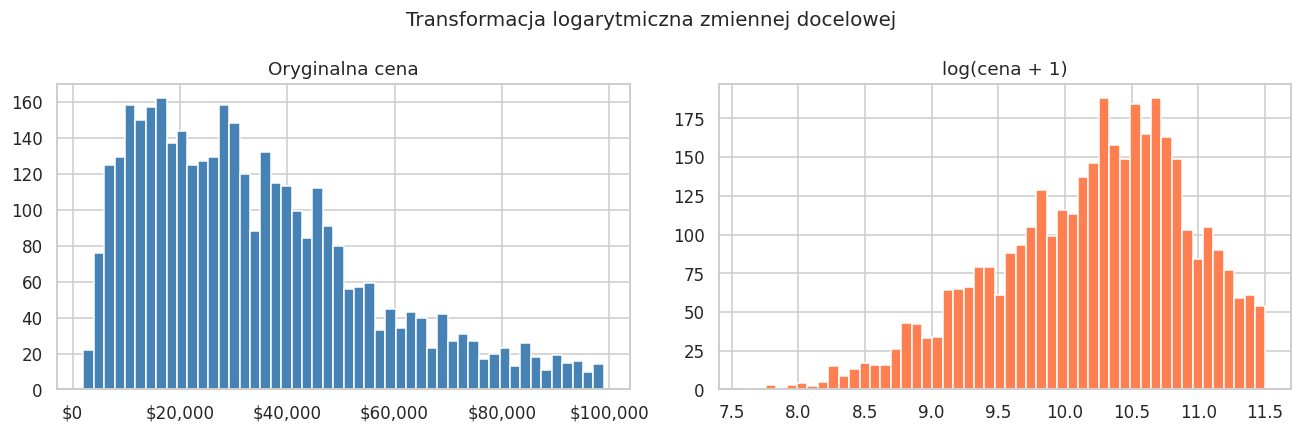

In [ ]:
df['log_price'] = np.log1p(df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Oryginalna cena')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].hist(df['log_price'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('log(cena + 1)')
plt.suptitle('Transformacja logarytmiczna zmiennej docelowej', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Podział na zbiór treningowy i testowy

In [ ]:
feature_cols = [c for c in df.columns
                if c not in [TARGET, 'log_price']]
X = df[feature_cols].copy()
y = df['log_price'].values

In [ ]:
print(f'Wszystkie cechy ({len(feature_cols)}):', feature_cols)

Wszystkie cechy (12): ['brand', 'milage', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'hp', 'engine_size', 'cylinders', 'model_main', 'car_age']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Trening: {X_train.shape[0]:,} próbek')
print(f'Test:    {X_test.shape[0]:,} próbek')

Trening: 2,960 próbek
Test:    740 próbek


### 5.4 Podział na cechy i target + skalowanie StandardScaler
Zbiór dzielony jest na cechy wejściowe `X` oraz zmienną docelową `y` (`log_price`). Następnie dane są standaryzowane przy użyciu **StandardScaler** — każda cecha numeryczna zostaje przekształcona do średniej 0 i odchylenia standardowego 1. Scaler jest dopasowywany wyłącznie na zbiorze treningowym, a następnie aplikowany do zbioru testowego, co zapobiega **data leakage**.

In [ ]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### 5.5 Funkcja ewaluacji modeli

Modele trenowane są na log-cenie — wyniki są dekodowane z powrotem do skali USD (`expm1`), aby metryki RMSE i MAE były interpretowalne.

In [ ]:
results = {}

def evaluate(name, y_true, y_pred, show_plot=True):
    y_true_usd = np.expm1(y_true)
    y_pred_usd = np.expm1(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
    mae  = mean_absolute_error(y_true_usd, y_pred_usd)
    r2   = r2_score(y_true, y_pred)

    print(f'\n=== {name} ===')
    print(f'  RMSE : ${rmse:,.0f}')
    print(f'  MAE  : ${mae:,.0f}')
    print(f'  R²   : {r2:.4f}')

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

    if show_plot:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(y_true_usd, y_pred_usd, alpha=0.3, s=15, color='steelblue')
        mn, mx = min(y_true_usd.min(), y_pred_usd.min()), max(y_true_usd.max(), y_pred_usd.max())
        ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
        ax.set_xlabel('Cena rzeczywista (USD)')
        ax.set_ylabel('Cena przewidywana (USD)')
        ax.set_title(f'{name}\nRMSE=${rmse:,.0f}  MAE=${mae:,.0f}  R²={r2:.4f}')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        plt.tight_layout()
        plt.show()

    return rmse, mae, r2

## 6. Trenowanie i optymalizacja modeli

### 6.1 Random Forest — optymalizacja liczby drzew

**Random Forest** to algorytm, który zamiast budować jedno drzewo decyzyjne, buduje ich wiele (las) — każde na losowym fragmencie danych. Finalna predykcja to średnia ze wszystkich drzew.

In [ ]:
param_grid = {
    'n_estimators':      [150, 180, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 0.5, 0.8, 1.0]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

grid_search.fit(X_train, y_train)

print(f'Najlepsze parametry: {grid_search.best_params_}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Najlepsze parametry: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}



=== Random Forest ===
  RMSE : $8,739
  MAE  : $5,926
  R²   : 0.8568


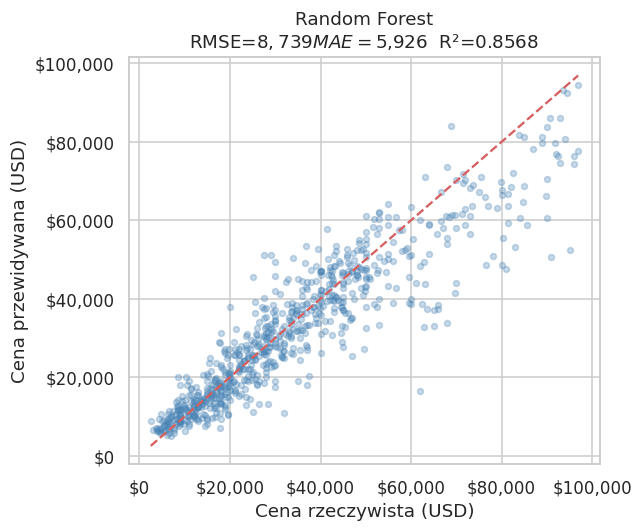

(np.float64(8739.081504772814), 5926.1216932491, 0.8568001858805749)

In [ ]:
best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test)
evaluate('Random Forest', y_test, rf_pred)

Do strojenia hiperparametrów użyto **RandomizedSearchCV** z 50 losowymi kombinacjami i walidacją krzyżową (5 foldów), co dało łącznie 250 dopasowań.

Najlepsze parametry: 200 drzew, głębokość maksymalna 30, połowa cech brana pod uwagę przy każdym podziale (`max_features=0.5`) oraz minimalna liczba próbek w liściu równa 1.

Model osiągnął **R²=0.857** — wyjaśnia ponad 80% zmienności cen — przy średnim błędzie bezwzględnym **MAE=$5,926**.

### 6.2 Ważność cech — Random Forest

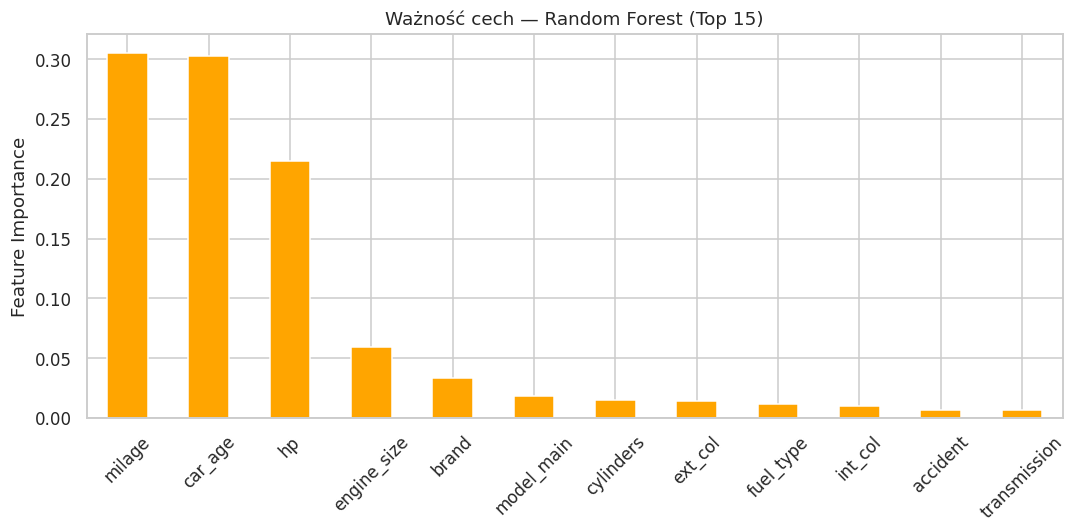

In [ ]:
feat_imp = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', ax=ax, color='orange', edgecolor='white')
ax.set_title('Ważność cech — Random Forest (Top 15)')
ax.set_ylabel('Feature Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 6.3 SVR — optymalizacja jądra i hiperparametrów

### 6.3 SVR — optymalizacja jądra i hiperparametrów
**Support Vector Regression (SVR)** dopasowuje model tak, by większość predykcji mieściła się w określonym marginesie błędu (ε). Trzy kluczowe hiperparametry to:
- `kernel`: funkcja jądra (rbf, linear, poly)
- `C`: regularyzacja — wyższe C = mniejszy margines
- `epsilon`: szerokość tuby epsilon

In [ ]:
param_dist_svr = {
    'kernel':  ['rbf', 'linear'],
    'C':       [10.0, 50.0, 100.0],
    'epsilon': [0.05, 0.1, 0.2],
    'gamma':   ['scale', 'auto'],
}

svr_search = RandomizedSearchCV(
    SVR(),
    param_distributions=param_dist_svr,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=1
)
svr_search.fit(X_train, y_train)
print('\nNajlepsze parametry SVR:', svr_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Najlepsze parametry SVR: {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.05, 'C': 100.0}



=== SVR ===
  RMSE : $10,130
  MAE  : $6,738
  R²   : 0.8236


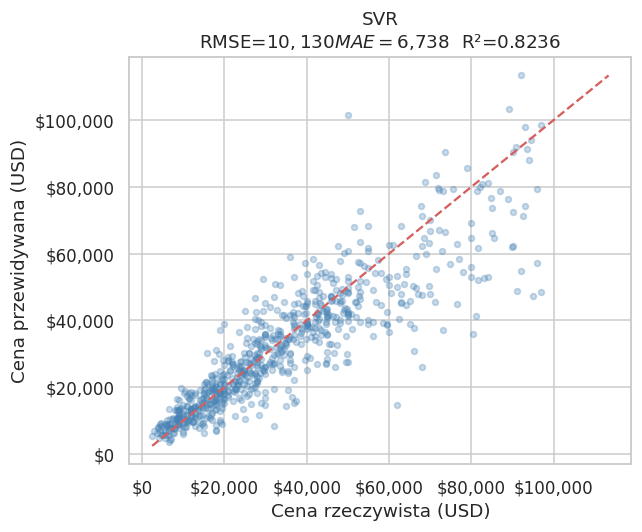

(np.float64(10130.260022996212), 6738.130317546077, 0.823564295549306)

In [ ]:
best_svr = svr_search.best_estimator_
svr_pred = best_svr.predict(X_test)
evaluate('SVR', y_test, svr_pred)

Hiperparametry dobrano metodą **RandomizedSearchCV** (30 kombinacji, 3 foldy). Najlepsze: `kernel=rbf`, `C=100`, `epsilon=0.05`.

Model osiągnął **R²=0.824**, co oznacza że wyjaśnia około 75% zmienności cen, przy średnim błędzie **MAE=$6,738**. Wynik dobry, jednak gorszy od Random Forest — SVR na większych zbiorach danych traci przewagę nad metodami ensemble.

### 6.4 SVR — porównanie jąder

kernel=rbf   : R²=0.8236, RMSE=$10,130
kernel=linear: R²=0.7578, RMSE=$14,005
kernel=poly  : R²=0.7577, RMSE=$12,526


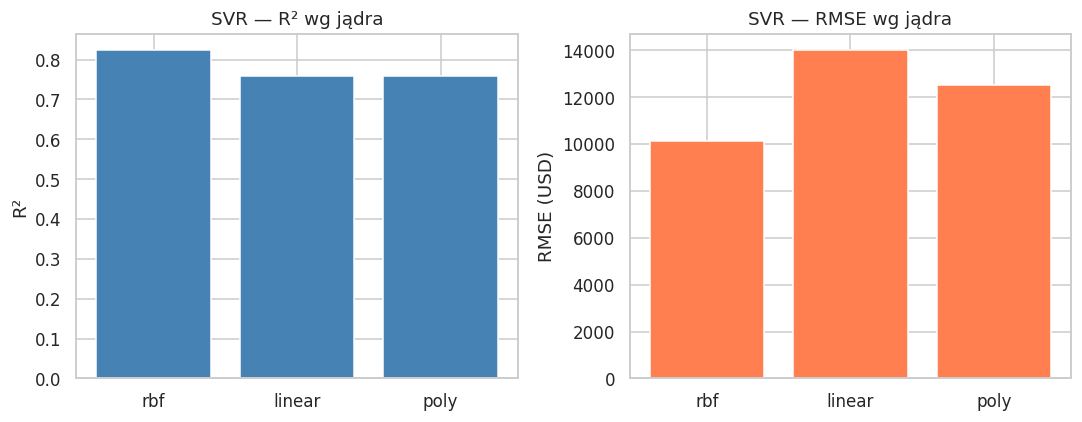

In [ ]:
best_params = svr_search.best_params_.copy()
kernels = ['rbf', 'linear', 'poly']
kernel_results = []

for k in kernels:
    params = {**best_params, 'kernel': k}
    svr_k = SVR(**params)
    svr_k.fit(X_train, y_train)
    pred_k = svr_k.predict(X_test)
    r2_k = r2_score(y_test, pred_k)
    rmse_k = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_k)))
    kernel_results.append({'kernel': k, 'R²': r2_k, 'RMSE': rmse_k})
    print(f'kernel={k:6s}: R²={r2_k:.4f}, RMSE=${rmse_k:,.0f}')

kernel_df = pd.DataFrame(kernel_results)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(kernel_df['kernel'], kernel_df['R²'], color='steelblue', edgecolor='white')
axes[0].set_title('SVR — R² wg jądra')
axes[0].set_ylabel('R²')
axes[1].bar(kernel_df['kernel'], kernel_df['RMSE'], color='coral', edgecolor='white')
axes[1].set_title('SVR — RMSE wg jądra')
axes[1].set_ylabel('RMSE (USD)')
plt.tight_layout()
plt.show()

### Ważność cech — SVR

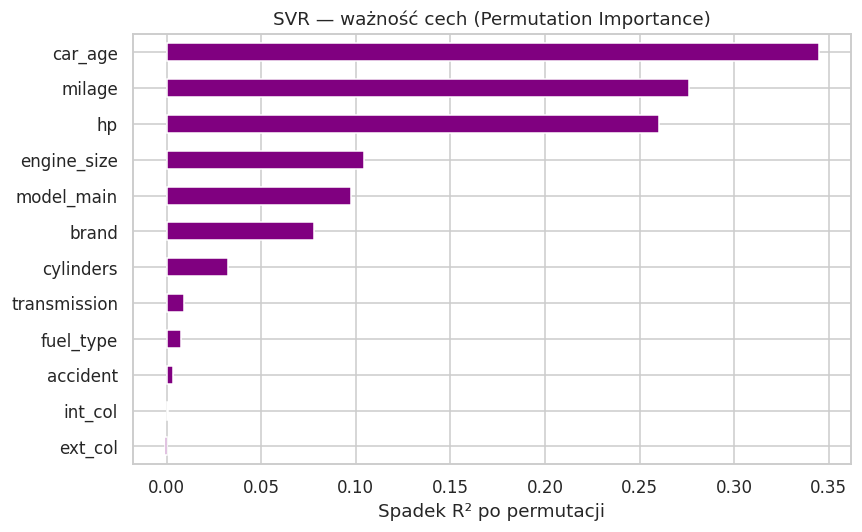

In [ ]:
perm_svr = permutation_importance(
    svr_search.best_estimator_, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

feat_imp_svr = pd.Series(perm_svr.importances_mean, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp_svr.plot(kind='barh', ax=ax, color='purple', edgecolor='white')
ax.set_title('SVR — ważność cech (Permutation Importance)')
ax.set_xlabel('Spadek R² po permutacji')
plt.tight_layout()
plt.show()

### 6.5 MLPRegressor (scikit-learn) — optymalizacja architektury i funkcji aktywacji

**MLPRegressor** to sieć neuronowa z scikit-learn — działa jak klasyczny model ML, bez potrzeby konfigurowania frameworka głębokiego uczenia. Uczy się nieliniowych zależności między cechami, co czyni ją dobrą alternatywą dla drzew decyzyjnych gdy dane mają złożoną strukturę. Najważniejsze hiperparametry to:
- **`hidden_layer_sizes`** — ile warstw i neuronów ma sieć, np. `(256, 128)` to dwie warstwy
- **`activation`** — funkcja aktywacji (`relu` działa najlepiej dla regresji)
- **`alpha`** — regularyzacja L2, zapobiega przeuczeniu
- **`learning_rate_init`** — krok uczenia, wpływa na szybkość i stabilność treningu

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64)],
    'activation':         ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.0005],
    'alpha':              [0.0001, 0.001],
    'batch_size':         [64, 128],
}

mlp = MLPRegressor(
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)

grid_search_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_grid,
    n_iter=30,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)


grid_search_mlp.fit(X_train, y_train)

print(f'Najlepsze parametry: {grid_search_mlp.best_params_}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Najlepsze parametry: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (256, 128), 'batch_size': 128, 'alpha': 0.0001, 'activation': 'tanh'}



=== MLP ===
  RMSE : $9,833
  MAE  : $6,805
  R²   : 0.8315


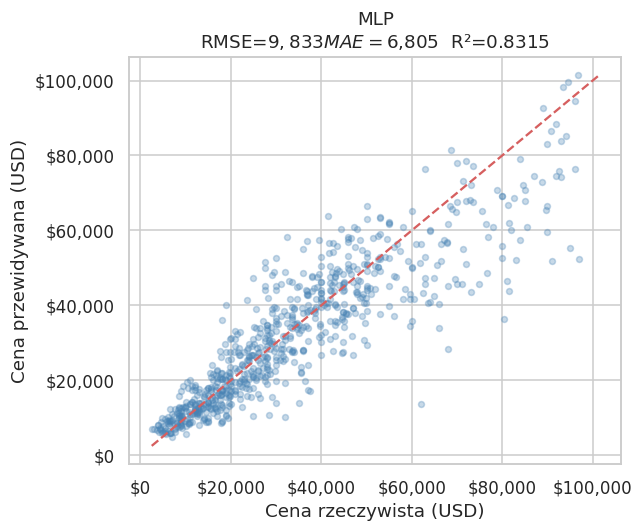

(np.float64(9832.521063622382), 6805.156717205327, 0.8314967830106503)

In [ ]:
best_mlp = grid_search_mlp.best_estimator_
mlp_pred = best_mlp.predict(X_test)
evaluate('MLP', y_test, mlp_pred)

Hiperparametry dobrano metodą **RandomizedSearchCV** (30 kombinacji, 5 foldów). Najlepsze: architektura `(256, 128)`, aktywacja `tanh`, learning rate `0.001`.

Model osiągnął **R²=0.832** przy **MAE=$6,805** — wynik zbliżony do SVR, jednak lepszy. Sieć neuronowa skutecznie uchwytuje nieliniowe zależności, choć nadal ustępuje Random Forest.

### 6.6 Wykres: R² wg architektury i aktywacji — MLP sklearn

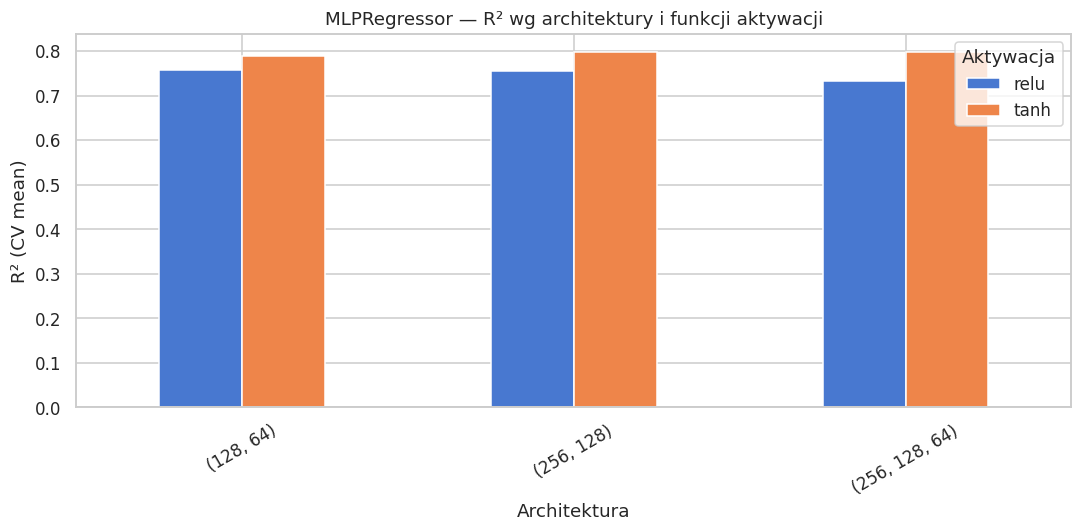

In [ ]:
cv_df = pd.DataFrame(grid_search_mlp.cv_results_)

pivot = cv_df.pivot_table(
    index='param_hidden_layer_sizes',
    columns='param_activation',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('MLPRegressor — R² wg architektury i funkcji aktywacji')
ax.set_ylabel('R² (CV mean)')
ax.set_xlabel('Architektura')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Aktywacja')
plt.tight_layout()
plt.show()

### Ważność cech — MLP (sklearn)

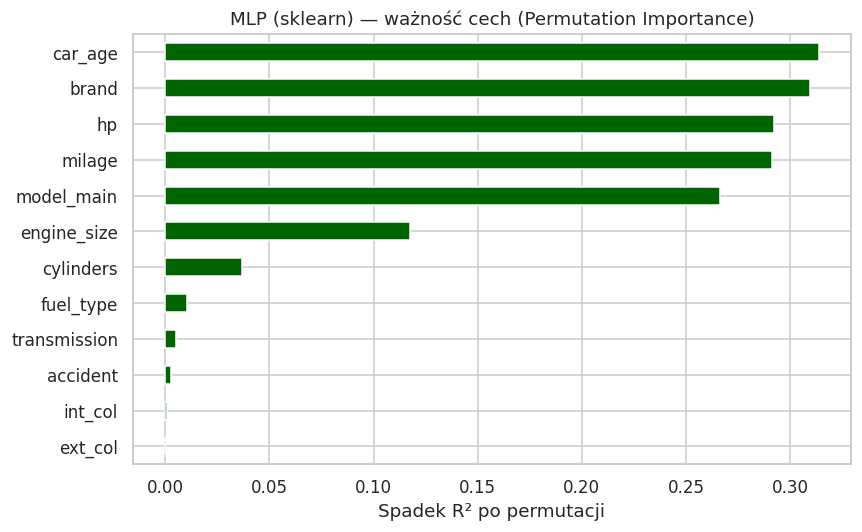

In [ ]:
perm_mlp = permutation_importance(
    grid_search_mlp.best_estimator_, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

feat_imp_mlp = pd.Series(perm_mlp.importances_mean, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp_mlp.plot(kind='barh', ax=ax, color='darkgreen', edgecolor='white')
ax.set_title('MLP (sklearn) — ważność cech (Permutation Importance)')
ax.set_xlabel('Spadek R² po permutacji')
plt.tight_layout()
plt.show()

### 6.7 MLP (TensorFlow/Keras) — optymalizacja architektury

**Keras** daje pełną kontrolę nad architekturą sieci — w odróżnieniu od `MLPRegressor` można dowolnie konfigurować każdą warstwę. Testujemy 5 architektur różniących się liczbą i rozmiarem warstw. Inicjalizacja wag dobierana jest automatycznie do funkcji aktywacji (`he_normal` dla `relu`/`elu`, `glorot_uniform` dla `tanh`). Trening stabilizowany jest przez dwa callbacki: **EarlyStopping** zatrzymuje uczenie gdy model przestaje się poprawiać, a **ReduceLROnPlateau** zmniejsza learning rate gdy trening utknął w plateau.

In [ ]:
n_features = X_train.shape[1]

ARCHITECTURES = {
    'Małe (128-64)':         [128, 64],
    'Średnie (256-128-64)':  [256, 128, 64],
    'Duże (512-256-128)':    [512, 256, 128],
    'Głębokie (256-128-64-32)': [256, 128, 64, 32],
    'Szerokie (512-512-256)':   [512, 512, 256],
}

CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
]

def build_mlp(n_feat, layers_sizes, activation='relu', lr=0.001):
    initializer = 'he_normal' if activation in ['relu', 'elu'] else 'glorot_uniform'

    model = keras.Sequential()
    model.add(layers.Input(shape=(n_feat,)))
    for size in layers_sizes:
        model.add(layers.Dense(size, activation=activation,
                               kernel_initializer=initializer))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    return model

print(f'Liczba cech wejściowych: {n_features}')

Liczba cech wejściowych: 12


### 6.8 Porównanie funkcji aktywacji Keras

In [ ]:
activations_keras = ['relu', 'elu', 'tanh']
act_results = {}

for act in activations_keras:
    tf.keras.backend.clear_session()
    model = build_mlp(n_features, [256, 128, 64], activation=act)
    model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=150,
        batch_size=64,
        callbacks=CALLBACKS,
        verbose=0
    )
    pred = model.predict(X_test, verbose=0).flatten()
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred)))
    act_results[act] = {'R²': r2, 'RMSE': rmse}
    print(f'activation={act:5s}: R²={r2:.4f}, RMSE=${rmse:,.0f}')

best_act = max(act_results, key=lambda a: act_results[a]['R²'])
print(f'\nNajlepsza funkcja aktywacji: {best_act}')

activation=relu : R²=0.6075, RMSE=$34,493
activation=elu  : R²=0.8064, RMSE=$10,549
activation=tanh : R²=-0.0158, RMSE=$22,718

Najlepsza funkcja aktywacji: elu


### 6.9 Porównanie architektur Keras

In [ ]:
arch_results = {}

for arch_name, arch_layers in ARCHITECTURES.items():
    tf.keras.backend.clear_session()
    model = build_mlp(n_features, arch_layers, activation=best_act, lr=0.0005)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=150,
        batch_size=64,
        callbacks=callbacks,
        verbose=0
    )
    y_pred = model.predict(X_test, verbose=0).flatten()
    rmse, mae, r2 = evaluate(f'Keras [{arch_name}]', y_test, y_pred, show_plot=False)
    arch_results[arch_name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2,
                                'epochs': len(history.history['loss'])}


=== Keras [Małe (128-64)] ===
  RMSE : $10,831
  MAE  : $7,341
  R²   : 0.8136

=== Keras [Średnie (256-128-64)] ===
  RMSE : $10,974
  MAE  : $7,584
  R²   : 0.8036

=== Keras [Duże (512-256-128)] ===
  RMSE : $10,995
  MAE  : $7,457
  R²   : 0.7999

=== Keras [Głębokie (256-128-64-32)] ===
  RMSE : $11,220
  MAE  : $7,594
  R²   : 0.7886

=== Keras [Szerokie (512-512-256)] ===
  RMSE : $10,303
  MAE  : $7,001
  R²   : 0.8183


### Wykres: RMSE vs architektura

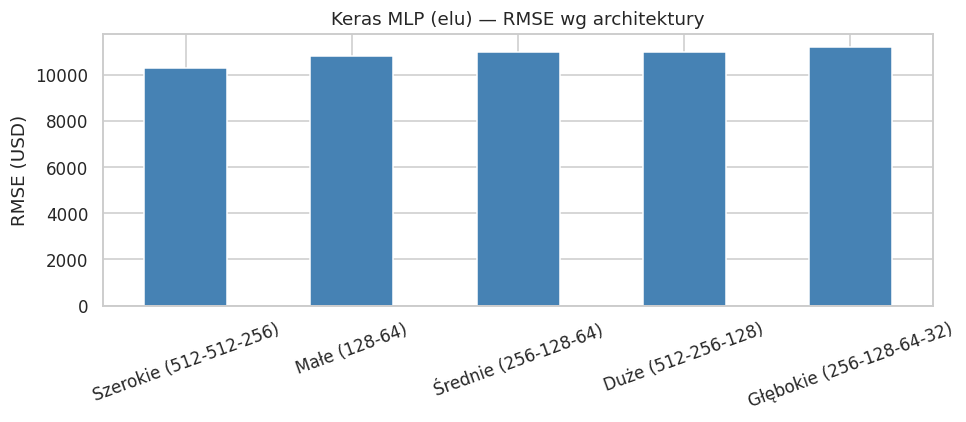

                             RMSE     MAE   R²  epochs
Szerokie (512-512-256)   10303.33 7001.08 0.82  101.00
Małe (128-64)            10830.74 7340.76 0.81  131.00
Średnie (256-128-64)     10974.46 7584.10 0.80  126.00
Duże (512-256-128)       10995.20 7457.44 0.80   54.00
Głębokie (256-128-64-32) 11220.49 7593.61 0.79   80.00


In [ ]:
arch_df = pd.DataFrame(arch_results).T.sort_values('RMSE')

fig, ax = plt.subplots(figsize=(9, 4))
arch_df['RMSE'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Keras MLP ({best_act}) — RMSE wg architektury')
ax.set_ylabel('RMSE (USD)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print(arch_df[['RMSE', 'MAE', 'R²', 'epochs']].to_string())

### Najlepsza architektura Keras — pełna ewaluacja z wykresem

Najlepsza architektura: Szerokie (512-512-256)

=== Keras MLP ===
  RMSE : $10,822
  MAE  : $7,379
  R²   : 0.8071


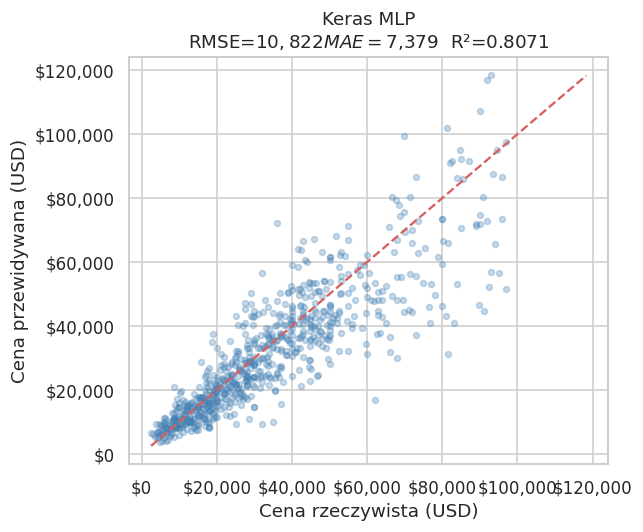

(np.float64(10822.436810074496), 7379.018292071367, 0.807071499415511)

In [ ]:
best_arch_name = arch_df.index[0]
print(f'Najlepsza architektura: {best_arch_name}')

tf.keras.backend.clear_session()
tf.random.set_seed(42)

best_arch = ARCHITECTURES[best_arch_name]
final_keras = build_mlp(n_features, best_arch, activation=best_act, lr=0.0005)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
]

final_history = final_keras.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=64,
    callbacks=callbacks_final,
    verbose=0
)

keras_final_pred = final_keras.predict(X_test, verbose=0).flatten()
evaluate(f'Keras MLP',
          y_test, keras_final_pred)

Spośród pięciu testowanych architektur najlepszą okazała się sieć **Szerokie (512-512-256)** z funkcją aktywacji **`elu`** i learning rate `0.0005`. Obniżony learning rate (względem domyślnego 0.001) był kluczowy dla stabilnego treningu — `elu` jest wrażliwe na zbyt duży krok uczenia. Trening stabilizowany był dodatkowo przez `EarlyStopping` i `ReduceLROnPlateau`, który automatycznie redukował learning rate o połowę gdy model przestawał się poprawiać. Finalny model osiągnął **R²=0.807** i **RMSE=$10,822** — wynik dobry, choć niższy niż Random Forest i MLP sklearn, co potwierdza że głębokie sieci neuronowe nie mają przewagi nad klasycznymi metodami ML przy zbiorach danych tej wielkości.

### Ważność cech — Keras MLP

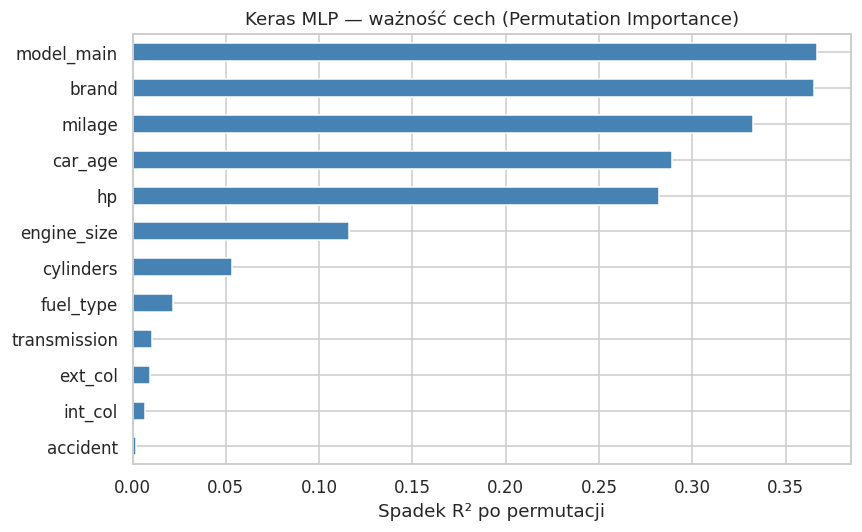

In [ ]:
class KerasWrapper(BaseEstimator, RegressorMixin):
    def fit(self, X, y): return self
    def predict(self, X): return final_keras.predict(X, verbose=0).flatten()

perm = permutation_importance(
    KerasWrapper(), X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

feat_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Keras MLP — ważność cech (Permutation Importance)')
ax.set_xlabel('Spadek R² po permutacji')
plt.tight_layout()
plt.show()

## 7. Porównanie modeli

Zestawienie wyników wszystkich modeli za pomocą tabel i wykresów słupkowych.

In [ ]:
summary_models = ['Random Forest', 'MLP', 'SVR', 'Keras MLP']
results_df = pd.DataFrame(results).T
results_df = results_df[results_df.index.isin(summary_models)]
results_df = results_df.sort_values('R²', ascending=False)
results_df['RMSE'] = results_df['RMSE'].apply(lambda x: f'${x:,.0f}')
results_df['MAE']  = results_df['MAE'].apply(lambda x: f'${x:,.0f}')
results_df['R²']   = results_df['R²'].apply(lambda x: f'{x:.4f}')
print('\n=== PORÓWNANIE MODELI ===')
print(results_df.to_string())


=== PORÓWNANIE MODELI ===
                  RMSE     MAE      R²
Random Forest   $8,739  $5,926  0.8568
MLP             $9,833  $6,805  0.8315
SVR            $10,130  $6,738  0.8236
Keras MLP      $10,822  $7,379  0.8071


### Wykresy porównawcze

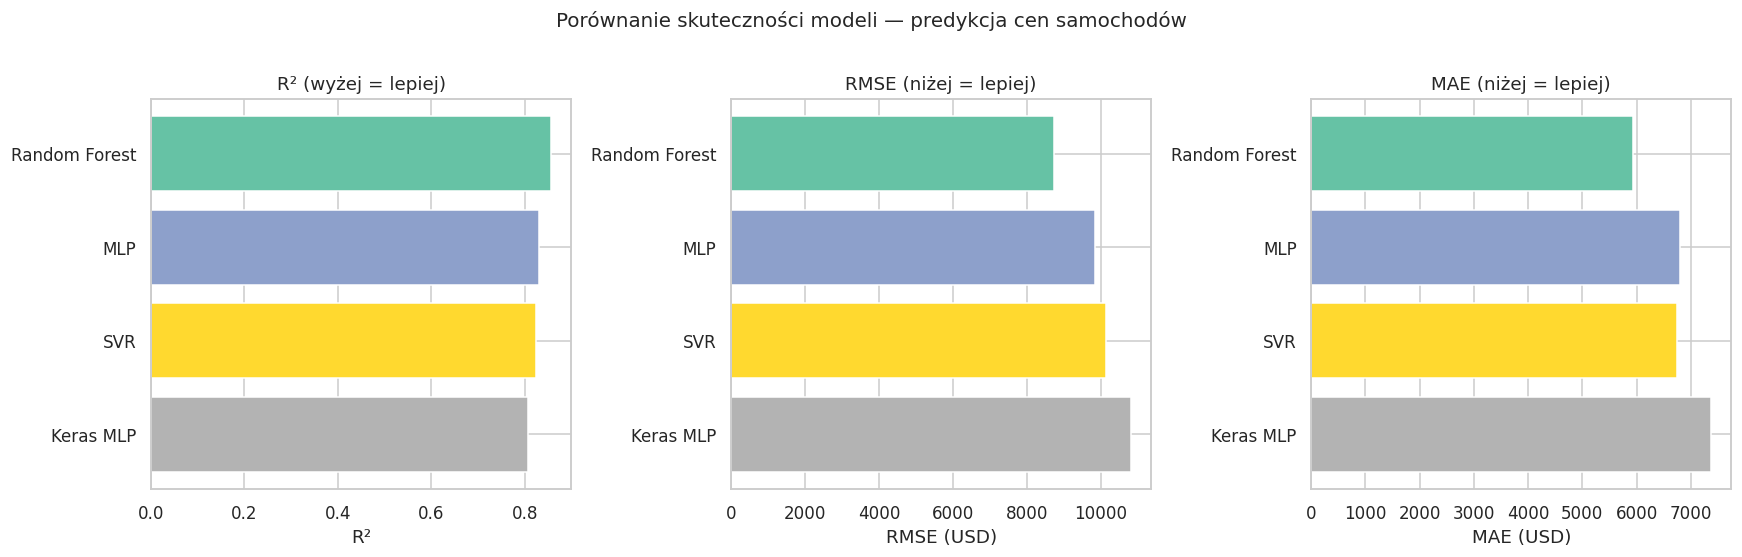

In [ ]:
summary_models = ['Random Forest', 'MLP', 'SVR', 'Keras MLP']
comp_df = pd.DataFrame(results).T
comp_df = comp_df[comp_df.index.isin(summary_models)]
comp_df = comp_df.sort_values('R²', ascending=False)

model_names = list(comp_df.index)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(comp_df)))

axes[0].barh(model_names, comp_df['R²'], color=colors, edgecolor='white')
axes[0].set_title('R² (wyżej = lepiej)')
axes[0].set_xlabel('R²')
axes[0].invert_yaxis()

axes[1].barh(model_names, comp_df['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('RMSE (niżej = lepiej)')
axes[1].set_xlabel('RMSE (USD)')
axes[1].invert_yaxis()

axes[2].barh(model_names, comp_df['MAE'], color=colors, edgecolor='white')
axes[2].set_title('MAE (niżej = lepiej)')
axes[2].set_xlabel('MAE (USD)')
axes[2].invert_yaxis()

plt.suptitle('Porównanie skuteczności modeli — predykcja cen samochodów',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

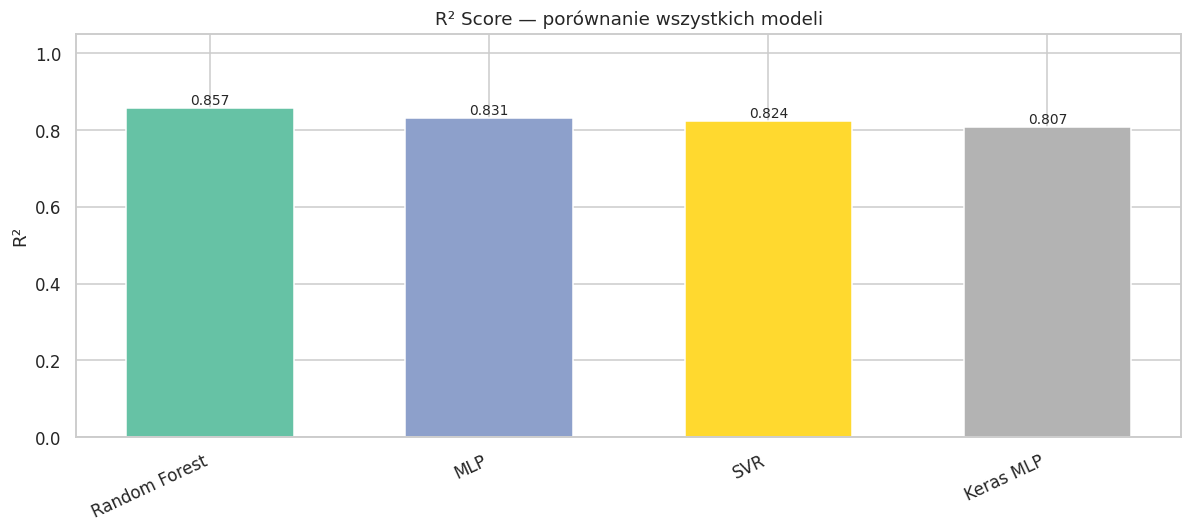

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comp_df))
ax.bar(x, comp_df['R²'], color=colors, edgecolor='white', width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha='right')
ax.set_title('R² Score — porównanie wszystkich modeli')
ax.set_ylabel('R²')
ax.set_ylim(0, 1.05)
for i, v in enumerate(comp_df['R²']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Wnioski

### 8.1 Najważniejsze cechy predykcyjne

Analiza ważności cech metodą Permutation Importance (oraz wbudowanego `feature_importances_` dla Random Forest) wykazała spójne wyniki we wszystkich modelach. Trzy cechy dominują jako najsilniejsze predyktory ceny:

- **`milage`** (przebieg) — najważniejsza cecha w Random Forest (0.305), wysoko we wszystkich modelach; im większy przebieg, tym niższa cena
- **`car_age`** (wiek pojazdu) — równorzędna z przebiegiem w RF (0.303), najważniejsza w MLP sklearn i SVR; potwierdza że starsze auta tracą na wartości
- **`hp`** (moc silnika) — trzecia najważniejsza cecha we wszystkich modelach; mocniejsze silniki oznaczają wyższe ceny

Cechy `engine_size` i `cylinders` mają umiarkowany wpływ i są częściowo redundantne względem `hp` — wszystkie trzy opisują parametry silnika.

Marka (`brand`) i model (`model_main`) mają duże znaczenie w Keras MLP i MLP sklearn, natomiast mniejsze w SVR i RF, co może wynikać z różnego sposobu przetwarzania zakodowanych zmiennych kategorycznych przez te algorytmy.

Cechy opisujące wygląd (`ext_col`, `int_col`), typ paliwa (`fuel_type`), skrzynię biegów (`transmission`) oraz historię wypadków (`accident`) mają marginalny wpływ na cenę we wszystkich modelach.

### 8.2 Porównanie modeli

| Model | R² | RMSE (USD) | Uwagi |
|:---|:---:|:---:|:---|
| Random Forest | 0.857 | 8 739 | Najlepszy wynik, odporny na outliery |
| MLP sklearn | 0.832 | 9 833 | Dobry wynik, szybki w treningu |
| SVR | 0.824 | 10 130 | Wolny na większych zbiorach |
| Keras MLP | 0.807 | 10 822 | Porównywalny z sklearn, większa złożoność konfiguracji |

Najlepsze wyniki osiągnął **Random Forest** (R²=0.857, RMSE=$8,739), co jest typowe dla danych tabelarycznych — algorytmy ensemble oparte na drzewach decyzyjnych dobrze radzą sobie z mieszanymi typami cech i nieliniowymi zależnościami. **MLP sklearn** i **SVR** uzyskały zbliżone wyniki (R²≈0.83 i 0.82), plasując się wyraźnie powyżej **Keras MLP** (R²=0.807). Mimo większej elastyczności architektonicznej, głębokie sieci neuronowe nie przewyższyły prostszych metod — przy zbiorze ~3700 próbek klasyczne algorytmy ML mają przewagę nad sieciami głębokimi, które wymagają znacznie większej ilości danych by w pełni wykorzystać swój potencjał. Wszystkie modele osiągnęły R²>0.80, co świadczy o dobrej jakości inżynierii cech.

### 8.3 Optymalne hiperparametry
- **Random Forest:** 200 drzew, `max_depth=30`, `max_features=0.5`, `min_samples_split=2`, `min_samples_leaf=1`
- **SVR:** jądro `rbf`, `C=100`, `epsilon=0.05`, `gamma=scale`
- **MLP sklearn:** architektura `(256, 128)`, aktywacja `tanh`, `learning_rate=0.001`, `alpha=0.0001`, `batch_size=128`
- **Keras MLP:** architektura `(512-512-256)`, aktywacja `elu`, `lr=0.0005`

### 8.4 Transformacja logarytmiczna
Zastosowanie `log1p(price)` jako zmiennej docelowej znacząco poprawiło wyniki modeli. Ceny samochodów mają rozkład prawostronnie skośny z długim ogonem — kilka bardzo drogich aut zaburzałoby uczenie. Transformacja logarytmiczna sprowadza rozkład do bardziej symetrycznego, co stabilizuje trening i zmniejsza wpływ wartości odstających.

### 8.5 Ekstrakcja cech
Parsowanie kolumny `engine` wyrażeniami regularnymi pozwoliło uzyskać `hp` i `engine_size` — dwie z najważniejszych cech w modelu. Stworzenie cechy `car_age` z roku produkcji również okazało się wartościowe. Pokazuje to że starannie przeprowadzona inżynieria cech ma często większy wpływ na wynik niż wybór algorytmu.

### 8.6 Przetwarzanie danych wejściowych przez algorytmy

**Random Forest** nie wymaga skalowania danych — drzewa decyzyjne podejmują decyzje na podstawie progów, więc skala cech nie ma znaczenia. Cechy kategoryczne zakodowane przez `LabelEncoder` do postaci liczb całkowitych są akceptowane bezpośrednio. Model radzi sobie również z wartościami odstającymi, ponieważ każde drzewo operuje na losowym podzbiorze danych i cech (bagging), co naturalnie ogranicza wpływ pojedynczych obserwacji.

**SVR** jest bardzo wrażliwy na skalę danych — algorytm opiera się na odległościach między punktami w przestrzeni cech, dlatego cechy o dużych wartościach bezwzględnych dominowałyby nad pozostałymi. Z tego powodu standaryzacja `StandardScaler` jest obowiązkowa przed treningiem. Scaler dopasowywany jest wyłącznie na zbiorze treningowym, a następnie aplikowany do zbioru testowego, co zapobiega data leakage. Zmienne kategoryczne muszą być zakodowane numerycznie — SVR nie obsługuje tekstu bezpośrednio.

**MLP sklearn (MLPRegressor)** również wymaga standaryzacji danych wejściowych. Sieć neuronowa propaguje sygnał przez kolejne warstwy za pomocą mnożenia macierzowego — cechy o dużych wartościach powodują duże aktywacje, co prowadzi do wolnej zbieżności lub eksplozji gradientów. Po standaryzacji wszystkie cechy mają średnią 0 i odchylenie standardowe 1, co zapewnia stabilny trening. Dane kategoryczne zakodowane przez `LabelEncoder` traktowane są jako numeryczne.

**Keras MLP** wymaga tych samych warunków wstępnych co MLPRegressor — standaryzacji danych wejściowych. Dodatkowo inicjalizacja wag dobierana jest do funkcji aktywacji: `he_normal` dla `relu` i `elu` (zachowuje wariancję sygnału przy aktywacjach asymetrycznych), `glorot_uniform` dla `tanh` (optymalna dla aktywacji symetrycznych). Poprawna inicjalizacja jest kluczowa dla głębszych architektur — zła inicjalizacja prowadzi do eksplozji lub zanikania gradientów, co objawiało się ujemnymi wartościami R² podczas eksperymentów. Trening stabilizowany jest przez `EarlyStopping` (zatrzymanie gdy model przestaje się poprawiać) oraz `ReduceLROnPlateau` (redukcja learning rate w plateau).